# K06_03 – Random Forest mit Moons

Update vom 24. Mai 2026

## Lernziele
- einen **unregulierten Entscheidungsbaum**, einen **regulierten Entscheidungsbaum** und einen **Random Forest** vergleichen
- Overfitting bei Einzelbäumen erkennen
- verstehen, warum Ensembles oft robuster generalisieren
- den Unterschied zwischen **einzelnem Testsplit** und **wiederholter Cross-Validation** erklären

## Didaktischer Hinweis

In diesem Notebook vergleichen wir **drei Verfahren**:

1. **Baum unreguliert**
2. **Baum reguliert**
3. **Random Forest**

Dadurch wird die zentrale Vorlesungsbotschaft klarer sichtbar:

- unregulierte Einzelbäume sind oft sehr flexibel und overfitten leicht
- regulierte Bäume sind robuster, aber begrenzter
- Random Forests liefern oft eine gute Balance aus Flexibilität und Stabilität

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import (
    train_test_split,
    RepeatedStratifiedKFold,
    cross_validate
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Datensatz erzeugen

Wir verwenden den `make_moons`-Datensatz mit etwas mehr Daten und etwas mehr Rauschen als zuvor.

Warum?
- Die Unterschiede zwischen den Verfahren werden dadurch oft sichtbarer.
- Das Beispiel wird robuster für die Vorlesung.

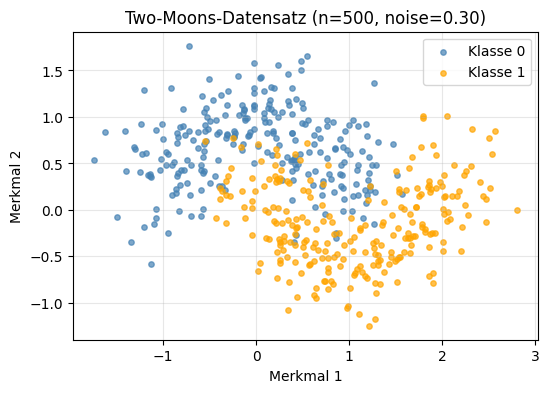

Shape von X: (500, 2)
Shape von y: (500,)


In [2]:
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)

plt.figure(figsize=(6, 4))
plt.scatter(X[y==0, 0], X[y==0, 1], color='steelblue', s=15,
            label='Klasse 0', alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1], color='orange', s=15,
            label='Klasse 1', alpha=0.7)
plt.xlabel('Merkmal 1')
plt.ylabel('Merkmal 2')
plt.title('Two-Moons-Datensatz (n=500, noise=0.30)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('Shape von X:', X.shape)
print('Shape von y:', y.shape)


## 2. Trainings- und Testdaten

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 3. Drei Modelle definieren

In [4]:
models = [
    ("Baum unreguliert", DecisionTreeClassifier(random_state=42)),
    ("Baum reguliert", DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=42)),
    ("Random Forest", RandomForestClassifier(n_estimators=300, random_state=42))
]

## 4. Erster Vergleich auf einem einzelnen Train/Test-Split

In [5]:
split_results = []
for name, clf in models:
    clf.fit(X_train, y_train)
    split_results.append({
        "Verfahren": name,
        "Train-Accuracy": clf.score(X_train, y_train),
        "Test-Accuracy": clf.score(X_test, y_test)
    })

split_df = pd.DataFrame(split_results).round(4)
split_df

,Verfahren,Train-Accuracy,Test-Accuracy
0,Baum unreguliert,1.0000,0.8667
1,Baum reguliert,0.9057,0.8800
2,Random Forest,1.0000,0.8933


## 5. Warum ein einzelner Testsplit noch nicht reicht

Der erste Vergleich ist nützlich, aber noch nicht belastbar genug.

Gründe:
- Das Ergebnis hängt immer auch von der **konkreten Datenaufteilung** ab.
- Ein einzelner Split kann einem Verfahren zufällig helfen oder schaden.
- Für die Vorlesung ist deshalb eine **robustere Bewertungsmethode** sinnvoll.

Wir verwenden daher jetzt eine **Repeated Cross-Validation**:
- 10 Folds
- 5 Wiederholungen

Dadurch wird der Vergleich stabiler und weniger zufallsabhängig.

## `RepeatedStratifiedKFold` erklärt

Der Befehl legt fest, **wie die Kreuzvalidierung durchgeführt wird**. Drei Konzepte stecken darin:

---

### 1. K-Fold – Daten in Blöcke aufteilen (`n_splits=10`)

Die Daten werden in **10 gleich große Blöcke** (Folds) aufgeteilt. Das Modell wird 10-mal trainiert — jedes Mal ist ein anderer Block der Testblock:

```
Fold 1:  [TEST][----Training----]
Fold 2:  [----][TEST][--Training-]
Fold 3:  [----][----][TEST][Train]
...
Fold 10: [----Training----][TEST]
```

Am Ende hat **jeder Datenpunkt genau einmal** als Testdaten gedient. Der finale Score ist der Durchschnitt aller 10 Fold-Scores — robuster als ein einzelner Train/Test-Split.

---

### 2. Stratified – Klassenverteilung erhalten (`Stratified`)

Beim normalen K-Fold kann es passieren, dass ein Fold zufällig kaum Beispiele einer Klasse enthält. Stratified verhindert das:

```
Gesamtdaten:  60% gutartig, 40% bösartig

Ohne Stratified:  Fold 3 könnte 90% gutartig, 10% bösartig enthalten  ✗
Mit Stratified:   Jeder Fold hat ~60% gutartig, ~40% bösartig          ✓
```

Besonders wichtig bei unbalancierten Datensätzen wie Breast Cancer.

---

### 3. Repeated – Mehrfach wiederholen (`n_repeats=5`)

Der gesamte 10-Fold-Prozess wird **5-mal wiederholt** — jedes Mal mit anderer zufälliger Aufteilung. Das ergibt insgesamt:

```
10 Splits × 5 Wiederholungen = 50 Modelle werden trainiert und bewertet
```

Warum? Ein einzelner 10-Fold-Lauf kann durch Zufall einen ungewöhnlich guten oder schlechten Score liefern. 5 Wiederholungen mitteln das heraus → **stabilerer, verlässlicherer Score**.

---

### `random_state=42` – Reproduzierbarkeit

Sorgt dafür, dass die zufälligen Aufteilungen immer gleich sind → jeder bekommt dasselbe Ergebnis.

---

### Zusammenfassung

| Parameter | Bedeutung | Wert hier |
|---|---|---|
| `n_splits=10` | Anzahl Blöcke | 10-Fold |
| `n_repeats=5` | Wie oft wiederholen | 5× |
| `Stratified` | Klassenverteilung erhalten | immer aktiv |
| `random_state=42` | Reproduzierbarkeit | fixiert |

> **Merksatz:** `RepeatedStratifiedKFold` ist die robusteste Standard-Kreuzvalidierung — sie bewertet das Modell fair, repräsentativ und stabil, weil sie weder Zufall noch Klassenungleichgewicht das Ergebnis verfälschen lässt.

In [6]:
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=5, random_state=42)

cv_results = []
for name, clf in models:
    scores = cross_validate(
        clf,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=True
    )
    cv_results.append({
        "Verfahren": name,
        "CV-Accuracy Mittelwert": scores["test_score"].mean(),
        "CV-Accuracy Std": scores["test_score"].std(),
        "Train-Accuracy Mittelwert": scores["train_score"].mean()
    })

cv_df = pd.DataFrame(cv_results).round(4)
cv_df.sort_values("CV-Accuracy Mittelwert", ascending=False)

,Verfahren,CV-Accuracy Mittelwert,CV-Accuracy Std,Train-Accuracy Mittelwert
2,Random Forest,0.8920,0.0466,1.0000
1,Baum reguliert,0.8708,0.0502,0.8987
0,Baum unreguliert,0.8576,0.0483,1.0000


## Feature Importance: Was lernt der Random Forest?

Ein zentraler Vorteil des Random Forest gegenueber dem Einzelbaum:
Feature Importance ist **stabiler**, weil sie über alle Bäume gemittelt wird.

Beim Two-Moons-Datensatz gibt es nur 2 Features (Merkmal 1 und 2).
Die Frage lautet: Haengt die Trennlinie eher von Merkmal 1 oder Merkmal 2 ab?


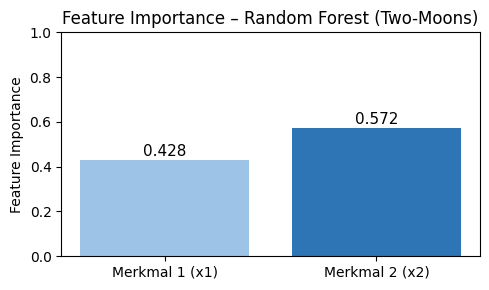

Beobachtung:
Merkmal 2 ist wichtiger (0.572 vs. 0.428)
-> Der Random Forest zeigt stabile Importance-Werte ueber alle 300 Baeume.
-> Ein Einzelbaum haette hier je nach Seed andere Werte geliefert.


In [7]:
import numpy as np

# Random-Forest-Modell aus der models-Liste holen
rf_model = [clf for name, clf in models if 'Forest' in name][0]

# Feature Importance
importances = rf_model.feature_importances_
feature_names = ['Merkmal 1 (x1)', 'Merkmal 2 (x2)']

plt.figure(figsize=(5, 3))
plt.bar(feature_names, importances,
        color=['#2E75B6' if i == importances.argmax() else '#9DC3E6'
               for i in range(len(importances))])
plt.ylabel('Feature Importance')
plt.title('Feature Importance – Random Forest (Two-Moons)')
plt.ylim(0, 1)
for i, v in enumerate(importances):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

print('Beobachtung:')
if importances[0] > importances[1]:
    print(f'Merkmal 1 ist wichtiger ({importances[0]:.3f} vs. {importances[1]:.3f})')
else:
    print(f'Merkmal 2 ist wichtiger ({importances[1]:.3f} vs. {importances[0]:.3f})')
print('-> Der Random Forest zeigt stabile Importance-Werte ueber alle 300 Baeume.')
print('-> Ein Einzelbaum haette hier je nach Seed andere Werte geliefert.')


## 6. Interpretation der Ergebnisse

In diesem Vergleich betrachten wir drei Verfahren:

1. einen **unregulierten Entscheidungsbaum**
2. einen **regulierten Entscheidungsbaum**
3. einen **Random Forest**

Typische Beobachtung:

- Der **unregulierte Baum** erreicht oft die höchste Trainingsgüte, zeigt aber die stärksten Hinweise auf Overfitting.
- Der **regulierte Baum** ist robuster, aber in seiner Flexibilität begrenzt.
- Der **Random Forest** erreicht häufig die beste oder eine sehr gute Testleistung bei gleichzeitig robusterem Verhalten.

Wichtig:
Für die Vorlesung ist **nicht entscheidend**, dass der Random Forest in jeder einzelnen Zahl klar gewinnt.
Wichtiger ist die methodische Einsicht:

> Einzelbäume sind instabiler und anfälliger für Overfitting, während Ensembles häufig robuster generalisieren.

## 7. Mini-Übungen

1. Welches Modell zeigt die stärksten Hinweise auf Overfitting?
2. Was verändert die Regularisierung am Einzelbaum?
3. Warum ist die wiederholte Cross-Validation hier didaktisch überzeugender als ein einzelner Testsplit?

## 8. Fazit

- Der **unregulierte Baum** ist sehr flexibel, aber anfällig für Overfitting.
- Der **regulierte Baum** ist kontrollierter, aber einfacher.
- Der **Random Forest** ist oft robuster und generalisiert stabiler.
- Für einen fairen Vergleich ist die **Repeated Cross-Validation** eine sehr gute Grundlage.

## 9. Musterlösungen und didaktische Hinweise

**Zu 1:** Meist der unregulierte Baum, weil er häufig nahezu perfekte Trainingswerte erreicht.

**Zu 2:** Die Regularisierung reduziert die Modellkomplexität, glättet die Entscheidungsgrenzen und macht das Modell robuster.

**Zu 3:** Weil die Ergebnisse über viele Aufteilungen gemittelt werden und dadurch weniger zufallsabhängig sind.

## Abschluss: Finales Modell

Der CV-Vergleich hat gezeigt: Random Forest ist das robusteste Verfahren.
Fuer den produktiven Einsatz trainieren wir das finale Modell auf **allen Daten**:


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Finales Modell auf allen 500 Datenpunkten
rf_final = RandomForestClassifier(n_estimators=300, random_state=42)
rf_final.fit(X, y)   # kein Split mehr -- alle Daten fliessen ins Training

print('Finales Random-Forest-Modell ist einsatzbereit.')
print(f'Anzahl Baeume: {rf_final.n_estimators}')

# Beispielvorhersage
neuer_punkt = [[0.5, 0.3]]
klasse = rf_final.predict(neuer_punkt)[0]
proba  = rf_final.predict_proba(neuer_punkt)[0]
print(f'Vorhersage fuer {neuer_punkt[0]}: Klasse {klasse}')
print(f'Wahrscheinlichkeiten: Klasse 0={proba[0]:.3f}, Klasse 1={proba[1]:.3f}')

print()
print('Merksatz: CV-Vergleich bewertet das Verfahren.')
print('          Das finale Modell trainiert auf allen Daten.')
